In [1]:
import warnings
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
import os
import glob
import numpy as np

from nilearn import datasets, surface
from nilearn import plotting
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
from nilearn.glm import threshold_stats_img
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.glm.second_level import SecondLevelModel, make_second_level_design_matrix 
from nilearn.surface import SurfaceImage
import nibabel as nib

from brainiak import image, io
from brainiak.isc import isc, isfc, permutation_isc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white", context="notebook", font_scale=1, rc={"lines.linewidth": 2})

In [2]:
bids_dir = "/home/NEU480/datasets/narratives/"
fmriprep_dir = bids_dir + "derivatives/fmriprep/"
cleaned_dir = bids_dir + "derivatives/afni-nosmooth/"
stimuli_dir = bids_dir + "stimuli/"
transcript_dir =  "/home/vm5631/stimuli/transcripts_with_events/"
dir_nilearn = "/home/NEU480/datasets/nilearn_data"
code_dir = bids_dir + "code/"
net_id = os.environ['USER']
scratch_folder = f"/scratch/network/{net_id}/"
thesis_folder = scratch_folder + "thesis/"
z_map_folder = thesis_folder + "z_maps/"

In [3]:
# Load the fsaverage6 mesh once (needed to construct SurfaceImage)
fsaverage6 = datasets.fetch_surf_fsaverage('fsaverage6', data_dir=thesis_folder)
fsaverage6_mesh = surface.PolyMesh(
    left=fsaverage6['pial_left'],
    right=fsaverage6['pial_right']
)

[fetch_surf_fsaverage] Dataset found in /scratch/network/vm5631/thesis/fsaverage6

In [4]:
import json
import pandas as pd


def json_to_events(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    events_list = []
    for event in data['annotations']['events']:
        events_list.append({
            'onset': event['start'],
            'duration': event['end'] - event['start'],
            'trial_type': event['label']  # e.g., 'punchline' or 'audience_laughter'
        })
    
    return pd.DataFrame(events_list)

In [5]:
def fetch_shared_punchlines(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    events_list = []
    for event in data['annotations']['events']:
        if 'shared_punchline_id' in event:
            events_list.append({
                'onset': event['start'],
                'duration': event['end'] - event['start'],
                'trial_type': event['label']  # e.g., 'punchline' or 'audience_laughter'
            })
    
    return pd.DataFrame(events_list)

In [6]:
events_live = json_to_events('stimuli/transcripts_with_events/pieman_audio.json')
events_pni = json_to_events('stimuli/transcripts_with_events/piemanpni_audio.json')
events_pni['onset'] = events_pni['onset'] + 12 # account for extra silence in the beginning

In [7]:
shared_punchlines_live = fetch_shared_punchlines('stimuli/transcripts_with_events/pieman_audio.json')
shared_punchlines_pni = fetch_shared_punchlines('stimuli/transcripts_with_events/piemanpni_audio.json')
shared_punchlines_pni['onset'] = shared_punchlines_pni['onset'] + 12

In [8]:
tr = 1.5
n_scans_live = 300
n_scans_pni = 294
trim_front_live = 10
trim_back_live = 8
trim_front_pni = 14
trim_back_pni = 13
exclude_subjects_live = [1, 13, 14, 21, 22, 38, 56, 68, 69]
subs_live = [(i + 1) for i in range(16, 82)]
exclude_subjects_pni = [266, 268, 269, 270, 271, 280]
subs_pni = [(i + 1) for i in range(264, 315)]
frame_times_live = np.arange(n_scans_live) * tr
frame_times_pni = np.arange(n_scans_pni) * tr

In [9]:
def remove_subjects(sub_list, exclude_list):
    cleaned_list = sub_list
    for sub in exclude_list:
        if sub in sub_list:
            cleaned_list.remove(sub) 
    return cleaned_list

In [10]:
subs_live = remove_subjects(subs_live, exclude_subjects_live)

In [11]:
subs_pni = remove_subjects(subs_pni, exclude_subjects_pni)
subs_pni.append(127)

In [12]:
import random

def get_random_items(data_list, count):
    # random.sample raises an error if count > len(data_list)
    if count > len(data_list):
        return "Count is larger than the list size!"
    
    return random.sample(data_list, count)

In [13]:
live_random = get_random_items(subs_live, 45)
live_random

[39,
 19,
 70,
 36,
 34,
 77,
 43,
 30,
 71,
 55,
 48,
 23,
 51,
 60,
 65,
 73,
 20,
 76,
 26,
 58,
 75,
 53,
 35,
 78,
 72,
 54,
 27,
 82,
 31,
 52,
 46,
 50,
 79,
 33,
 44,
 57,
 29,
 81,
 64,
 63,
 25,
 32,
 18,
 28,
 42]

In [14]:
pni_random = get_random_items(subs_pni, 45)
pni_random

[312,
 292,
 299,
 273,
 284,
 279,
 294,
 272,
 314,
 304,
 267,
 285,
 307,
 315,
 311,
 127,
 287,
 275,
 291,
 303,
 308,
 297,
 278,
 295,
 310,
 306,
 298,
 281,
 265,
 276,
 293,
 301,
 313,
 290,
 300,
 305,
 289,
 274,
 296,
 309,
 286,
 283,
 302,
 277,
 282]

In [15]:
spp_modified = shared_punchlines_pni
spp_modified['onset'] = shared_punchlines_pni['onset'] - 3

spl_modified = shared_punchlines_live
spl_modified['onset'] = shared_punchlines_live['onset'] - 3

In [16]:
def generate_z_maps_gifti(events, subs, task):
    """
    Run first-level GLM on GIfTI surface data.
    Both hemispheres are combined into a single SurfaceImage per subject.

    Returns a list of SurfaceImage z-maps, one per subject.
    """
    z_maps = []

    for sub in subs:
        gifti_imgs = {}
        for hemi, side in [('L', 'left'), ('R', 'right')]:
            file_name = (
                f"sub-{sub:03d}_task-{task}_space-fsaverage6"
                f"_hemi-{hemi}_desc-clean.func.gii"
            )
            file_dir = f"{cleaned_dir}sub-{sub:03d}/func/"
            gifti_imgs[side] = file_dir + file_name  # pass path, not loaded image

        surf_img = SurfaceImage(
            mesh=fsaverage6_mesh,
            data=gifti_imgs  # {'left': path_L, 'right': path_R}
        )

        print(f"sub-{sub:03d}: {surf_img.shape}")

        glm = FirstLevelModel(
            t_r=1.5,
            signal_scaling=False,
            noise_model='ar1',
            standardize=False
        )

        glm.fit(surf_img, events=events)
        z_maps.append(glm.compute_contrast('punchline', output_type='z_score'))

    return z_maps

In [17]:
z_maps_pni = generate_z_maps_gifti(spp_modified, pni_random, 'piemanpni')

sub-312: (81924, 294)
sub-292: (81924, 294)
sub-299: (81924, 294)
sub-273: (81924, 294)
sub-284: (81924, 294)
sub-279: (81924, 294)
sub-294: (81924, 294)
sub-272: (81924, 294)
sub-314: (81924, 294)
sub-304: (81924, 294)
sub-267: (81924, 294)
sub-285: (81924, 294)
sub-307: (81924, 294)
sub-315: (81924, 294)
sub-311: (81924, 294)
sub-127: (81924, 294)
sub-287: (81924, 294)
sub-275: (81924, 294)
sub-291: (81924, 294)
sub-303: (81924, 294)
sub-308: (81924, 294)
sub-297: (81924, 294)
sub-278: (81924, 294)
sub-295: (81924, 294)
sub-310: (81924, 294)
sub-306: (81924, 294)
sub-298: (81924, 294)
sub-281: (81924, 294)
sub-265: (81924, 294)
sub-276: (81924, 294)
sub-293: (81924, 294)
sub-301: (81924, 294)
sub-313: (81924, 294)
sub-290: (81924, 294)
sub-300: (81924, 294)
sub-305: (81924, 294)
sub-289: (81924, 294)
sub-274: (81924, 294)
sub-296: (81924, 294)
sub-309: (81924, 294)
sub-286: (81924, 294)
sub-283: (81924, 294)
sub-302: (81924, 294)
sub-277: (81924, 294)
sub-282: (81924, 294)


In [18]:
z_maps_live = generate_z_maps_gifti(spl_modified, live_random, 'pieman')

sub-039: (81924, 300)
sub-019: (81924, 300)
sub-070: (81924, 300)
sub-036: (81924, 300)
sub-034: (81924, 300)
sub-077: (81924, 300)
sub-043: (81924, 300)
sub-030: (81924, 300)
sub-071: (81924, 300)
sub-055: (81924, 300)
sub-048: (81924, 300)
sub-023: (81924, 300)
sub-051: (81924, 300)
sub-060: (81924, 300)
sub-065: (81924, 300)
sub-073: (81924, 300)
sub-020: (81924, 300)
sub-076: (81924, 300)
sub-026: (81924, 300)
sub-058: (81924, 300)
sub-075: (81924, 300)
sub-053: (81924, 300)
sub-035: (81924, 300)
sub-078: (81924, 300)
sub-072: (81924, 300)
sub-054: (81924, 300)
sub-027: (81924, 300)
sub-082: (81924, 300)
sub-031: (81924, 300)
sub-052: (81924, 300)
sub-046: (81924, 300)
sub-050: (81924, 300)
sub-079: (81924, 300)
sub-033: (81924, 300)
sub-044: (81924, 300)
sub-057: (81924, 300)
sub-029: (81924, 300)
sub-081: (81924, 300)
sub-064: (81924, 300)
sub-063: (81924, 300)
sub-025: (81924, 300)
sub-032: (81924, 300)
sub-018: (81924, 300)
sub-028: (81924, 300)
sub-042: (81924, 300)


In [19]:
def plot_z_map_surface(z_map, title="Z-map", threshold=3.1):
    """Plot a SurfaceImage z-map on both hemispheres, lateral and medial views."""
    plotting.plot_surf_stat_map(
        surf_mesh=fsaverage6_mesh,
        stat_map=z_map,
        hemi='left',
        view='lateral',
        title=f"{title} - Left (lateral)",
        threshold=threshold,
        colorbar=True,
        cmap='cold_hot'
    )
    plotting.plot_surf_stat_map(
        surf_mesh=fsaverage6_mesh,
        stat_map=z_map,
        hemi='right',
        view='lateral',
        title=f"{title} - Right (lateral)",
        threshold=threshold,
        colorbar=True,
        cmap='cold_hot'
    )
    plotting.show()

In [20]:
def plot_z_map_surface_all_views(z_map, title="Z-map", threshold=3.1):
    """Plot lateral and medial views for both hemispheres in one figure."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': '3d'})
    
    views = [('left', 'lateral'), ('left', 'medial'),
             ('right', 'lateral'), ('right', 'medial')]
    
    for ax, (hemi, view) in zip(axes.flat, views):
        plotting.plot_surf_stat_map(
            surf_mesh=fsaverage6_mesh,
            stat_map=z_map,
            hemi=hemi,
            view=view,
            title=f"{hemi} - {view}",
            threshold=threshold,
            colorbar=True,
            cmap='cold_hot',
            axes=ax
        )
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plotting.show()

In [21]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

def interactive_surface_plot(stat_map, threshold=1.3, title="", cmap='cold_hot'):
    """
    Interactive surface viewer with hemisphere/view dropdowns.
    Renders inline in Jupyter — change dropdowns to update without rerunning.
    """
    hemi_dropdown = widgets.Dropdown(
        options=[('Left', 'left'), ('Right', 'right')],
        value='left',
        description='Hemisphere:',
        layout=widgets.Layout(width='200px')
    )
    view_dropdown = widgets.Dropdown(
        options=['lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior'],
        value='lateral',
        description='View:',
        layout=widgets.Layout(width='200px')
    )
    out = widgets.Output()

    def update(change=None):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(
                figsize=(8, 6),
                subplot_kw={'projection': '3d'}
            )
            plotting.plot_surf_stat_map(
                surf_mesh=fsaverage6_mesh,
                stat_map=stat_map,
                hemi=hemi_dropdown.value,
                view=view_dropdown.value,
                threshold=threshold,
                colorbar=True,
                cmap=cmap,
                # title=f"{title} | {hemi_dropdown.value} {view_dropdown.value}",
                axes=ax
            )
            plt.tight_layout()
            plt.show()

    hemi_dropdown.observe(update, names='value')
    view_dropdown.observe(update, names='value')

    controls = widgets.HBox([hemi_dropdown, view_dropdown])
    display(widgets.VBox([controls, out]))
    update()  # render immediately on call

In [22]:
import ipywidgets as widgets
from IPython.display import display

def interactive_view_surf(stat_map, threshold=1.3, title=""):
    hemi_dropdown = widgets.Dropdown(
        options=[('Left', 'left'), ('Right', 'right')],
        value='left',
        description='Hemisphere:',
    )
    out = widgets.Output()

    def update(change=None):
        with out:
            out.clear_output(wait=True)
            view = plotting.view_surf(
                surf_mesh=fsaverage6_mesh.parts[hemi_dropdown.value],
                surf_map=stat_map.data.parts[hemi_dropdown.value],
                threshold=threshold,
                # title=f"{title} | {hemi_dropdown.value}"
            )
            display(view)

    hemi_dropdown.observe(update, names='value')
    display(widgets.VBox([hemi_dropdown, out]))
    update()

In [23]:
def run_second_level_gifti(z_maps_group1, z_maps_group2, 
                            label_group1='live', label_group2='pni',
                            alpha=0.05):
    """
    Run a second-level two-sample t-test on surface z-maps.
    
    Parameters
    ----------
    z_maps_group1 : list of SurfaceImage
        First-level z-maps for group 1 (one per subject)
    z_maps_group2 : list of SurfaceImage
        First-level z-maps for group 2 (one per subject)
    
    Returns
    -------
    dict with z-maps for: group1 > group2, group2 > group1, 
    and each group's one-sample effect
    """
    
    # Combine z-maps and build design matrix
    all_z_maps = z_maps_group1 + z_maps_group2
    n1, n2 = len(z_maps_group1), len(z_maps_group2)
    
    design_matrix = pd.DataFrame({
        label_group1: [1] * n1 + [0] * n2,
        label_group2: [0] * n1 + [1] * n2,
    })
    
    print(f"Design matrix ({n1 + n2} subjects):")
    print(design_matrix.value_counts())
    
    # Fit second level model
    second_level_model = SecondLevelModel(n_jobs=-1)
    second_level_model.fit(all_z_maps, design_matrix=design_matrix)
    
    # Contrasts
    contrasts = {
        f'{label_group1}_gt_{label_group2}': f'{label_group1} - {label_group2}',
        f'{label_group2}_gt_{label_group1}': f'{label_group2} - {label_group1}',
        f'{label_group1}_one_sample':         label_group1,
        f'{label_group2}_one_sample':         label_group2,
    }
    
    results = {}
    results_thresholded = {}
    for name, contrast_def in contrasts.items():
        results[name] = second_level_model.compute_contrast(
            contrast_def,
            output_type='z_score'
        )
        print(f"Computed: {name}")
        # Apply FDR correction
        thresholded_map, threshold = threshold_stats_img(
            results[name],
            alpha=alpha,
            height_control='fdr'   # swap to 'fpr' for uncorrected, 'bonferroni' for FWE
        )
        results_thresholded[name] = thresholded_map
        print(f"{name}: FDR threshold = {threshold:.3f}")
    
    return results, results_thresholded

In [24]:
second_level_results, second_level_results_thresholded = run_second_level_gifti(z_maps_live, z_maps_pni)

Design matrix (90 subjects):
live  pni
1     0      45
0     1      45
Name: count, dtype: int64
Computed: live_gt_pni
live_gt_pni: FDR threshold = 4.140
Computed: pni_gt_live
pni_gt_live: FDR threshold = 4.140
Computed: live_one_sample
live_one_sample: FDR threshold = 3.074
Computed: pni_one_sample
pni_one_sample: FDR threshold = 2.852


In [25]:
interactive_view_surf(second_level_results_thresholded["live_gt_pni"])

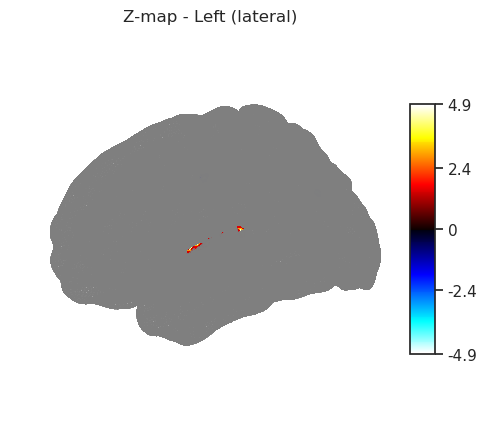

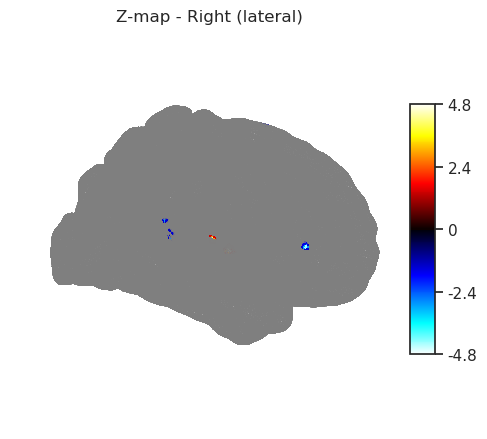

In [26]:
plot_z_map_surface(second_level_results_thresholded["live_gt_pni"], threshold=1e-6)